# Prédiction des charges médicales
## Projet Machine Learning — Master ISI

## 1. Introduction et description du dataset
Ce projet s’inscrit dans le cadre du module de Machine Learning et a pour objectif de prédire les charges médicales individuelles à partir de caractéristiques personnelles des assurés.
L’analyse repose sur un dataset contenant des informations démographiques et médicales telles que l’âge, le sexe, l’indice de masse corporelle (IMC), le nombre d’enfants, le statut de fumeur ainsi que la région de résidence. La variable cible est le montant des charges médicales.
Le dataset comprend **1339 observations** et **7 variables** :
- **Variables explicatives (features)** : `age`, `sex`, `bmi`, `children`, `smoker`, `region`  
- **Variable cible (target)** : `charges`

L’objectif principal est de construire des modèles de régression capables d’estimer ces charges avec précision, tout en identifiant les variables les plus influentes.

## 2. Importation des Librairies

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE

# ── Scikit-learn: Models ──────────────────────────────────────────────────────
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV,
    Lasso, LassoCV, ElasticNet, ElasticNetCV
)

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Statistical Modeling ──────────────────────────────────────────────────────
import statsmodels.api as sm

# ── Global Aesthetics ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
RANDOM_STATE = 42

print('Toutes les librairies importées avec succès.')

Toutes les librairies importées avec succès.


## 3. Chargement des Données

In [3]:
df = pd.read_csv('medical-charges.csv')
print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 1338 lignes × 7 colonnes


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


## 4. Analyse Exploratoire des Données (EDA)

### 4.1 Analyse Univariée

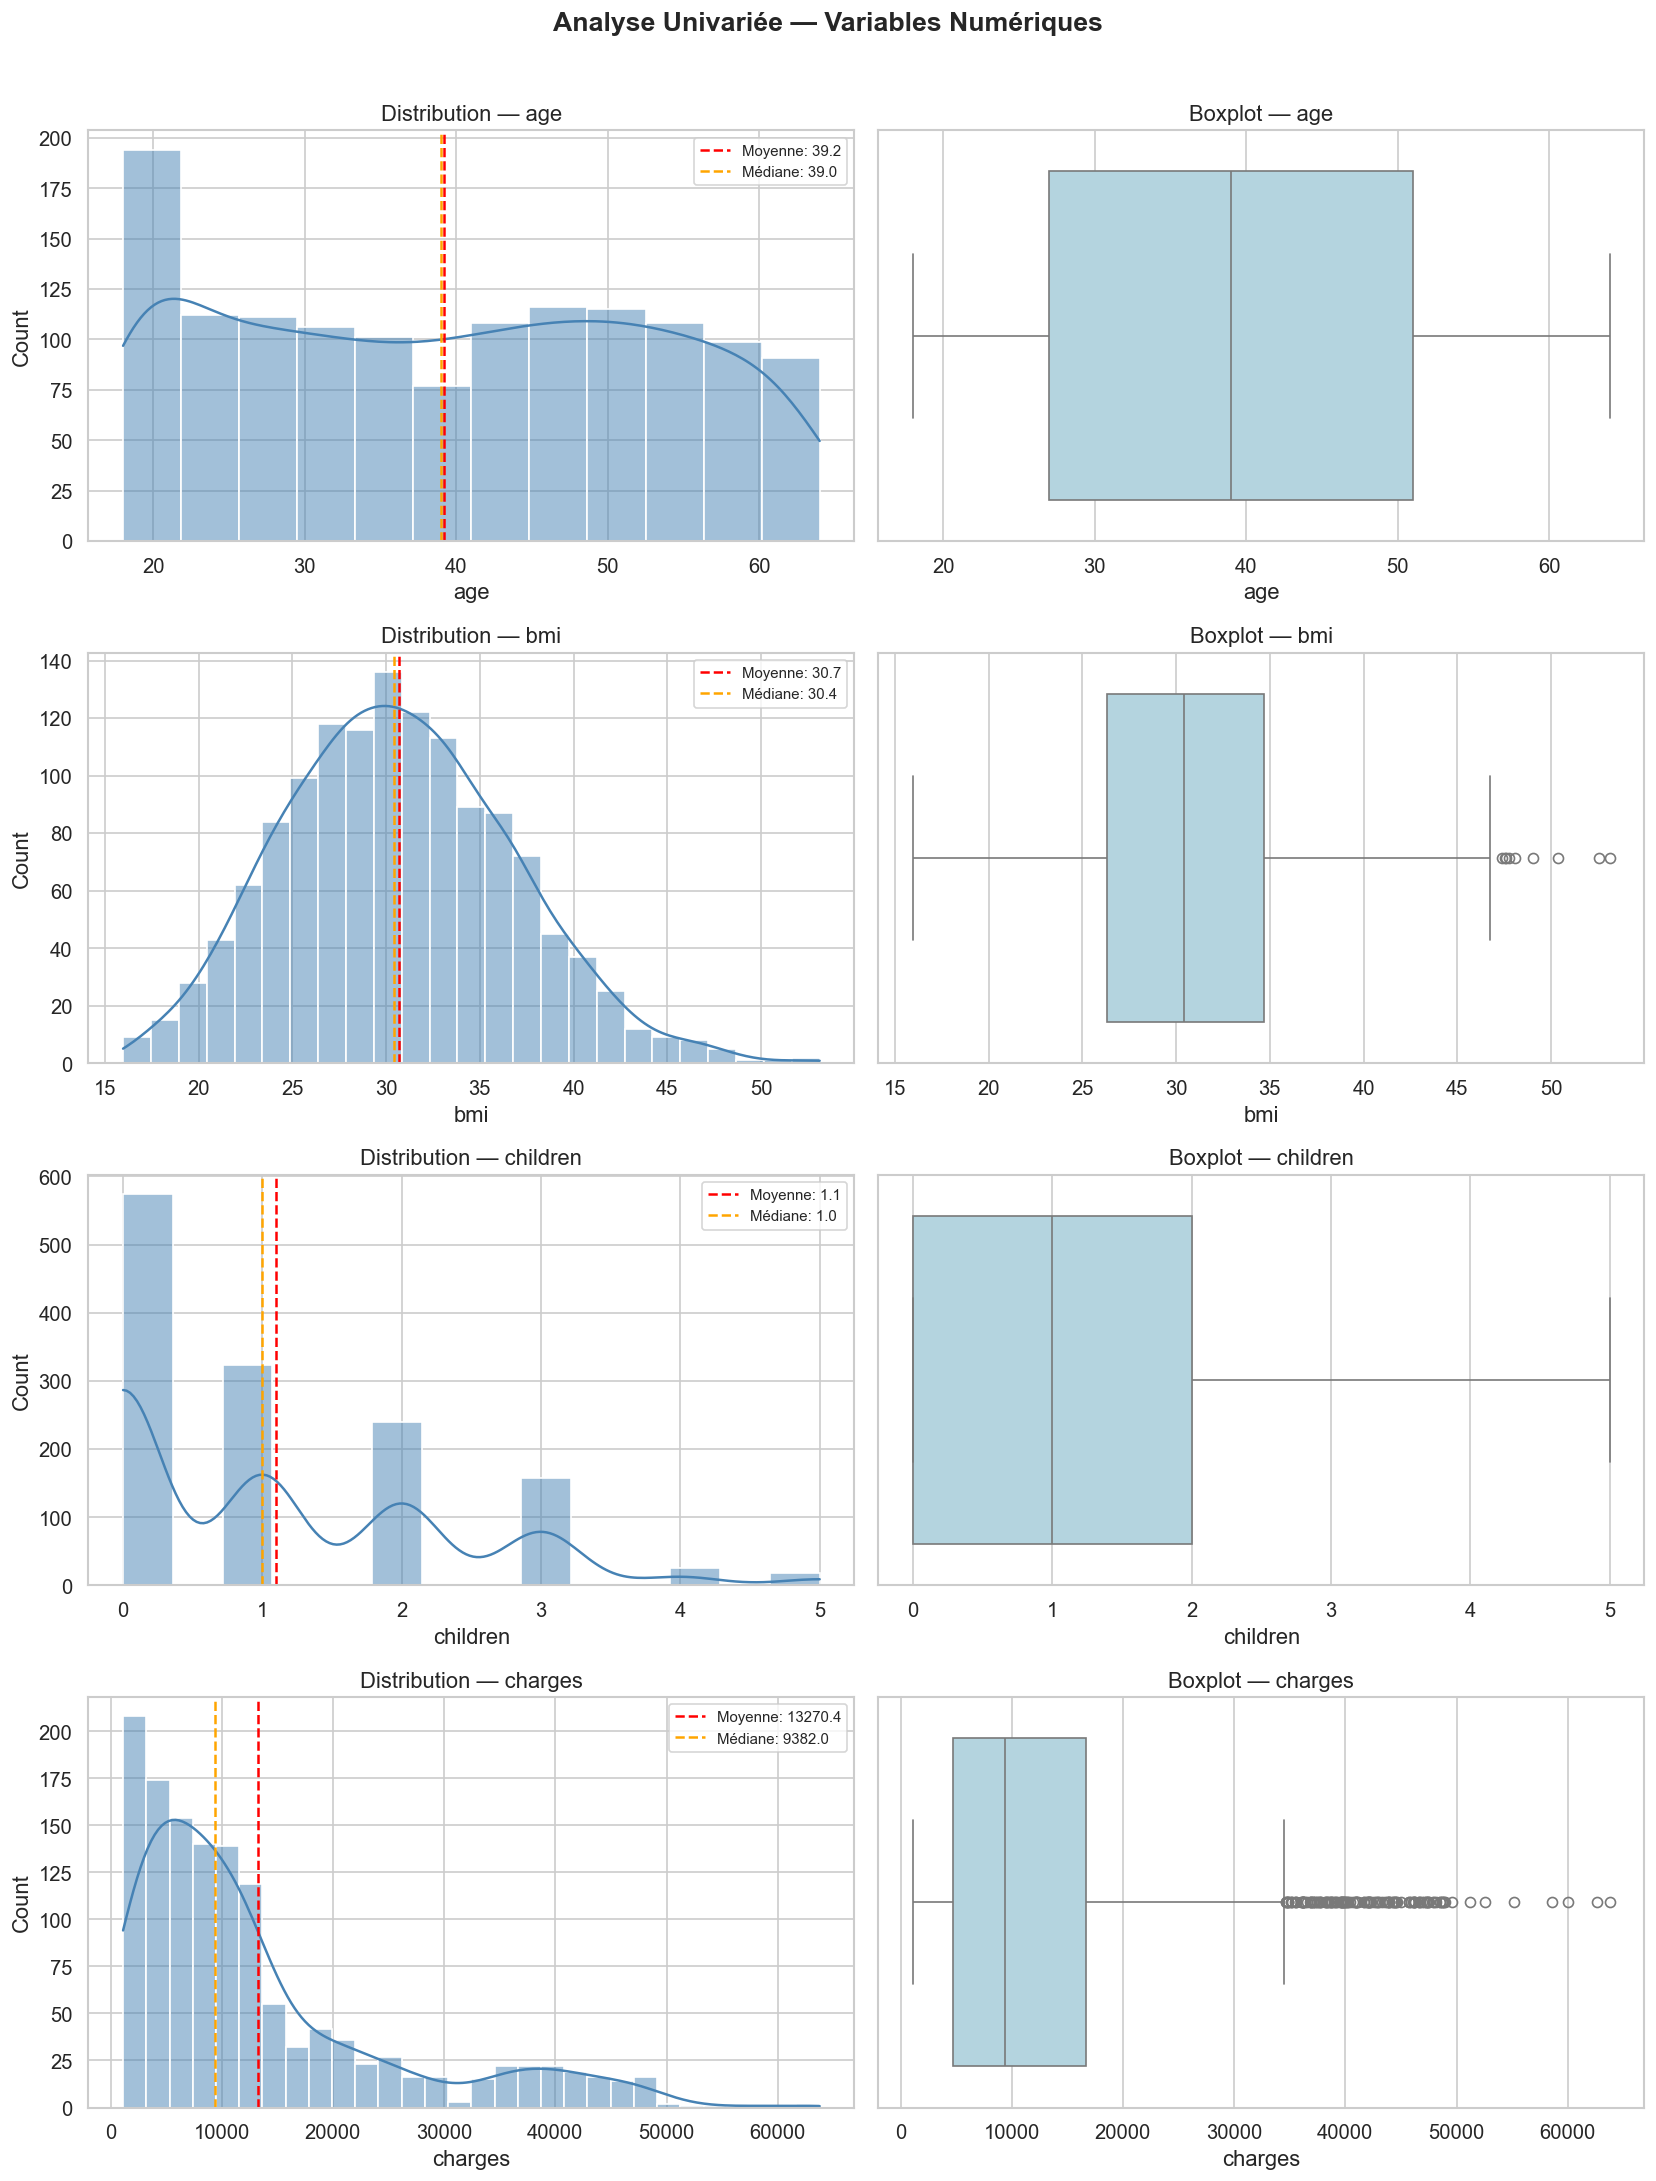

In [8]:
num_vars = ['age', 'bmi', 'children', 'charges']
cat_vars = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle('Analyse Univariée — Variables Numériques', fontsize=16, fontweight='bold', y=1.01)

for i, var in enumerate(num_vars):
    # Histogramme + KDE
    sns.histplot(df[var], kde=True, ax=axes[i, 0], color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'Distribution — {var}')
    axes[i, 0].axvline(df[var].mean(), color='red', linestyle='--', label=f'Moyenne: {df[var].mean():.1f}')
    axes[i, 0].axvline(df[var].median(), color='orange', linestyle='--', label=f'Médiane: {df[var].median():.1f}')
    axes[i, 0].legend(fontsize=9)
    # Boxplot
    sns.boxplot(x=df[var], ax=axes[i, 1], color='lightblue')
    axes[i, 1].set_title(f'Boxplot — {var}')

plt.tight_layout()
plt.savefig('fig_univariate_num.png', bbox_inches='tight')
plt.show()

> **Observations :** La variable `charges` présente une distribution fortement asymétrique à droite (right-skewed), ce qui suggère l'existence de sous-groupes à charges élevées. L'`age` est quasi-uniforme. L'`bmi` suit une distribution proche de la normale.

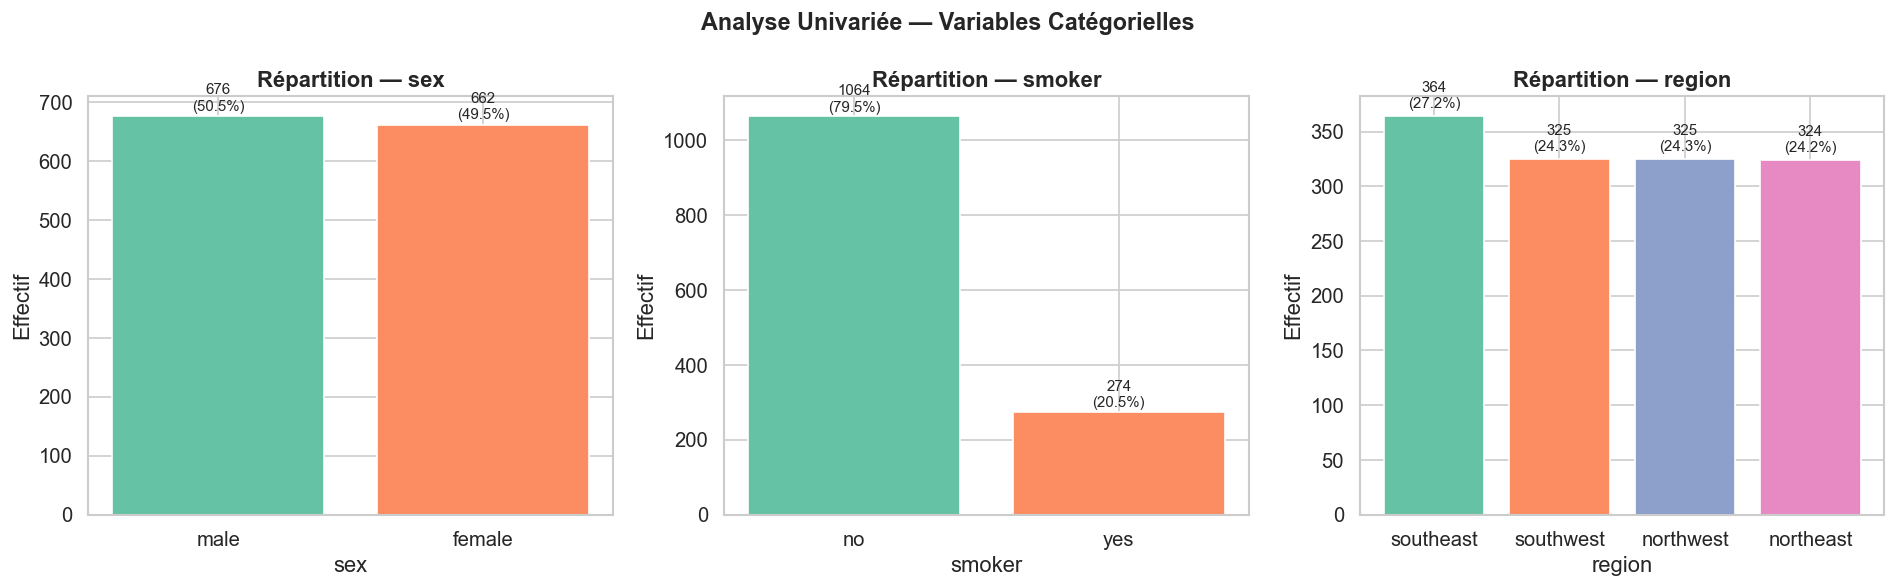

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analyse Univariée — Variables Catégorielles', fontsize=14, fontweight='bold')

palette = ['#4C9BE8', '#F28B82']
for i, var in enumerate(cat_vars):
    counts = df[var].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(f'Répartition — {var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Effectif')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig_univariate_cat.png', bbox_inches='tight')
plt.show()

> **Observations :** La distribution `sex` est quasi-équilibrée (50/50). Environ **20%** des bénéficiaires sont fumeurs (`smoker=yes`). Les 4 régions géographiques sont représentées de manière relativement homogène.

### 4.2 Analyse Bivariée

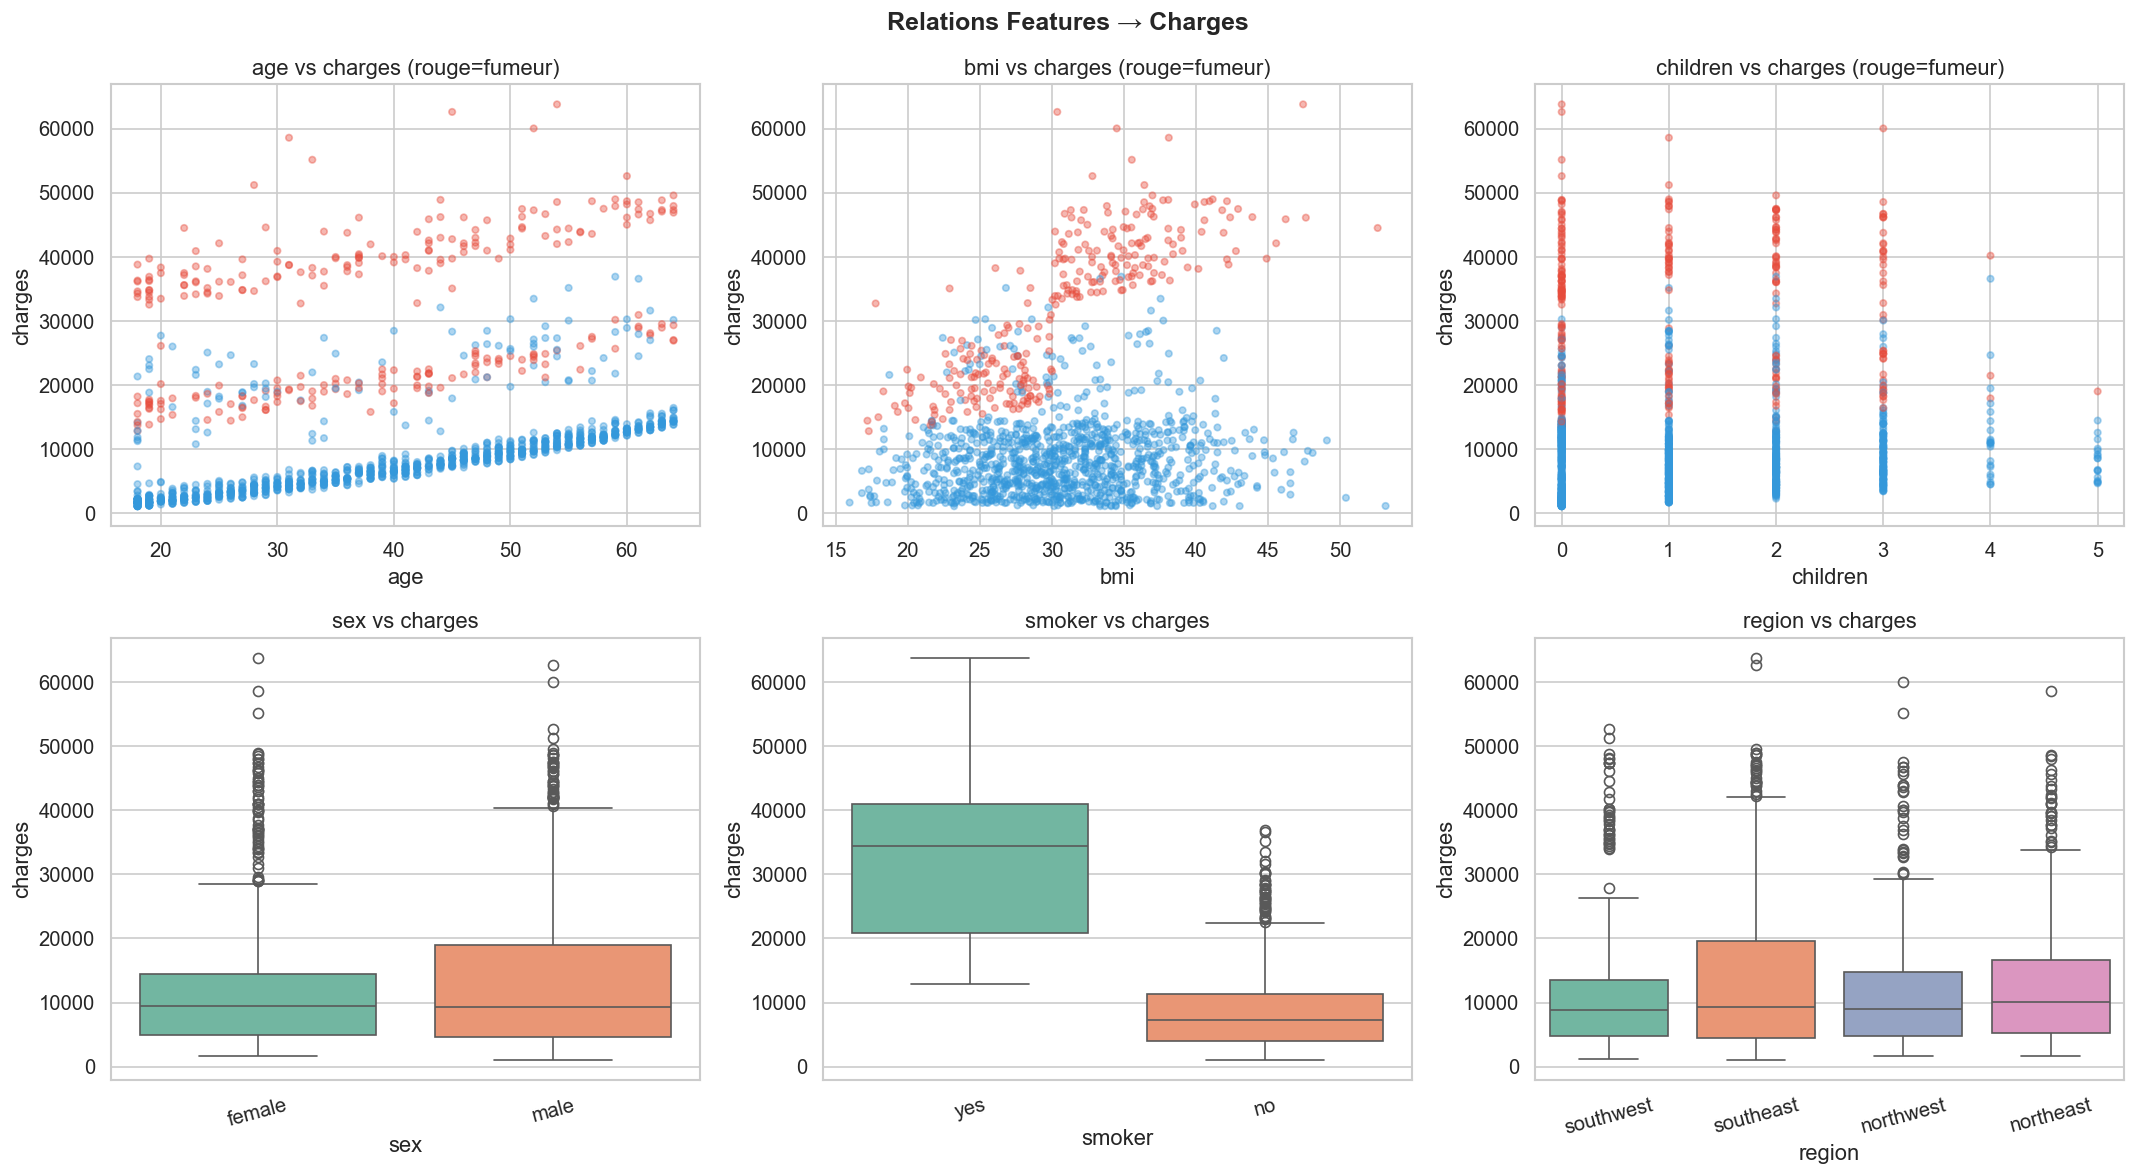

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Relations Features → Charges', fontsize=15, fontweight='bold')

# Numériques vs charges
for i, var in enumerate(['age', 'bmi', 'children']):
    hue_color = df['smoker'].map({'yes': '#E74C3C', 'no': '#3498DB'})
    axes[0, i].scatter(df[var], df['charges'], c=hue_color, alpha=0.4, s=15)
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel('charges')
    axes[0, i].set_title(f'{var} vs charges (rouge=fumeur)')

# Catégorielles vs charges
for i, var in enumerate(cat_vars):
    sns.boxplot(data=df, x=var, y='charges', ax=axes[1, i],
                palette='Set2', order=df[var].unique())
    axes[1, i].set_title(f'{var} vs charges')
    axes[1, i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig_bivariate.png', bbox_inches='tight')
plt.show()

> **Observations :**
> Variables numériques vs charges  
> - **age** : relation positive → les charges augmentent avec l’âge  
> - **bmi** : effet modéré → charges plus élevées pour BMI élevé, surtout chez les fumeurs  
> - **children** : influence faible sur les charges  

> Variables catégorielles vs charges  
> - **smoker** : impact très fort → les fumeurs ont des charges nettement plus élevées  
> - **sex** : impact faible → distributions similaires  
> - **region** : influence négligeable  

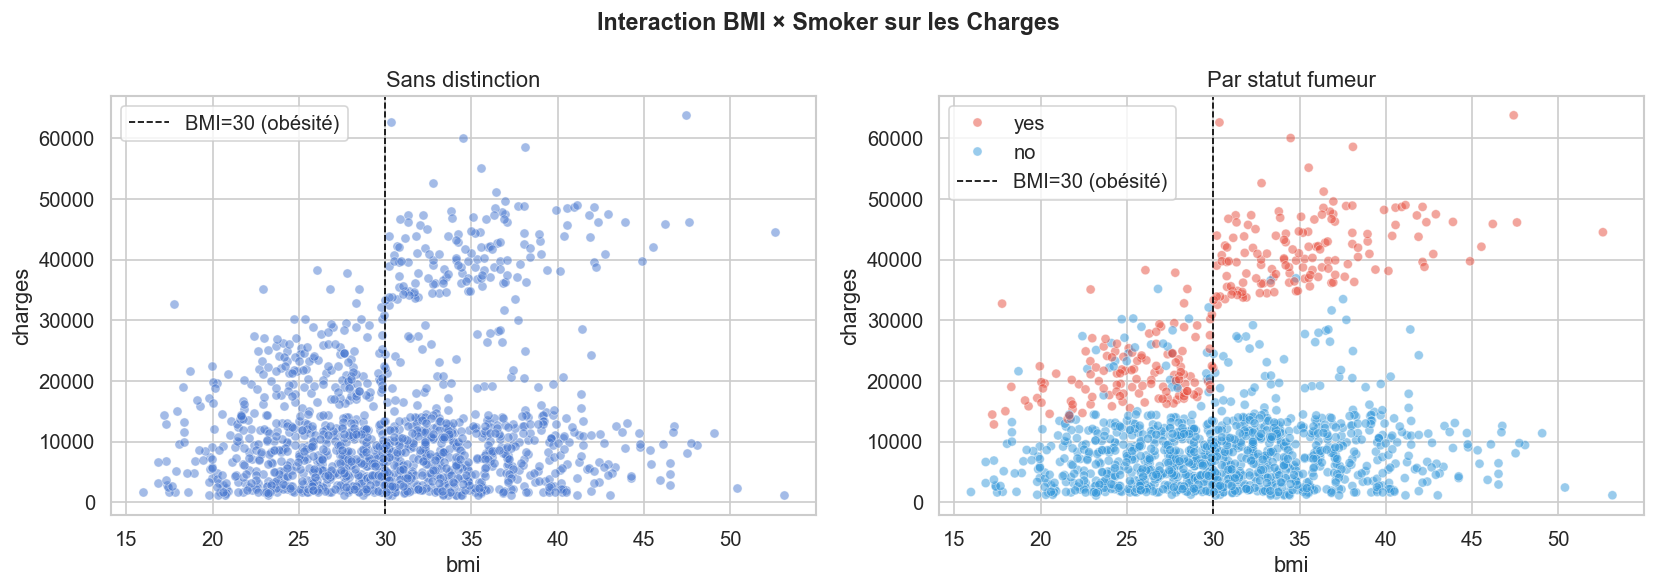

In [16]:
# Impact de l'interaction BMI × Smoker
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Interaction BMI × Smoker sur les Charges', fontsize=14, fontweight='bold')

for ax, hue in zip(axes, [None, 'smoker']):
    sns.scatterplot(data=df, x='bmi', y='charges', hue=hue,
                    palette={'yes': '#E74C3C', 'no': '#3498DB'} if hue else None,
                    alpha=0.5, s=30, ax=ax)
    ax.set_title('Sans distinction' if not hue else 'Par statut fumeur')
    ax.axvline(30, color='black', linestyle='--', linewidth=1, label='BMI=30 (obésité)')
    ax.legend()

plt.tight_layout()
plt.savefig('fig_bmi_smoker.png', bbox_inches='tight')
plt.show()

**Conclusion :**
- Le statut **fumeur** est le facteur le plus discriminant : les fumeurs paient en moyenne 3× plus que les non-fumeurs.
- L'**âge** présente une relation positive avec les charges, avec 3 clusters distincts (fumeurs BMI>30, fumeurs BMI<30, non-fumeurs).
- Un fumeur avec BMI ≥ 30 cumule les deux facteurs de risque → charges extrêmement élevées.

### 4.3 Analyse Multivariée

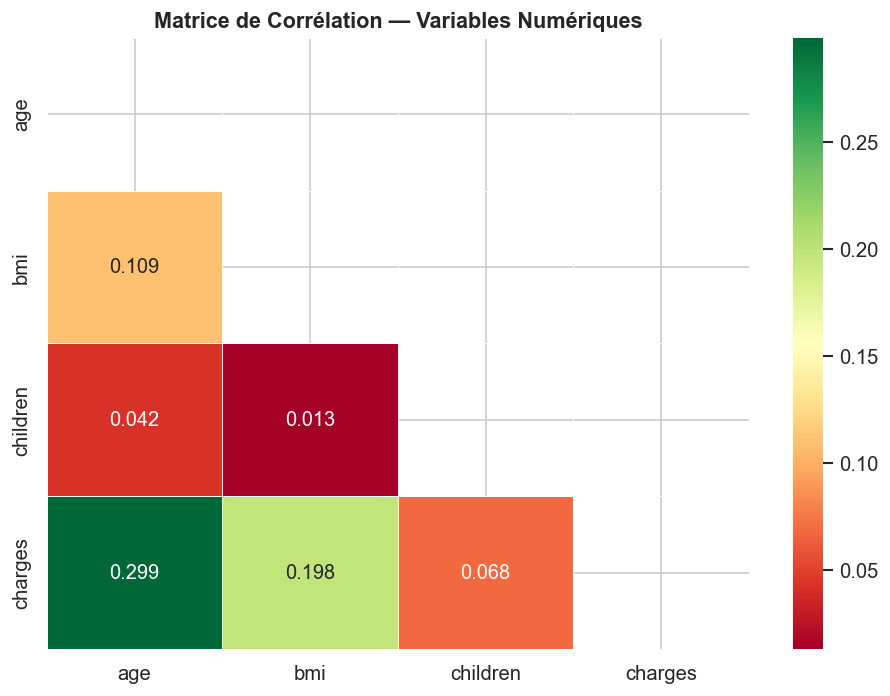

In [17]:
# Matrice de corrélation
corr_df = df[num_vars].copy()
corr = corr_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 12})
ax.set_title('Matrice de Corrélation — Variables Numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight')
plt.show()

#### Observations

| Paire de variables | Corrélation | Interprétation |
|---|---|---|
| `age` ↔ `charges` | **~0.299** | Corrélation positive modérée — les charges augmentent avec l'âge |
| `bmi` ↔ `charges` | **~0.198** | Corrélation positive faible — l'IMC seul explique peu les charges |
| `children` ↔ `charges` | **~0.068** | Corrélation quasi-nulle — le nombre d'enfants n'influence pas significativement les charges |
| `age` ↔ `bmi` | **~0.109** | Très faible corrélation — les deux variables sont quasi-indépendantes |
| `age` ↔ `children` | **~0.042** | Corrélation négligeable |
| `bmi` ↔ `children` | **~0.013** | Corrélation négligeable |

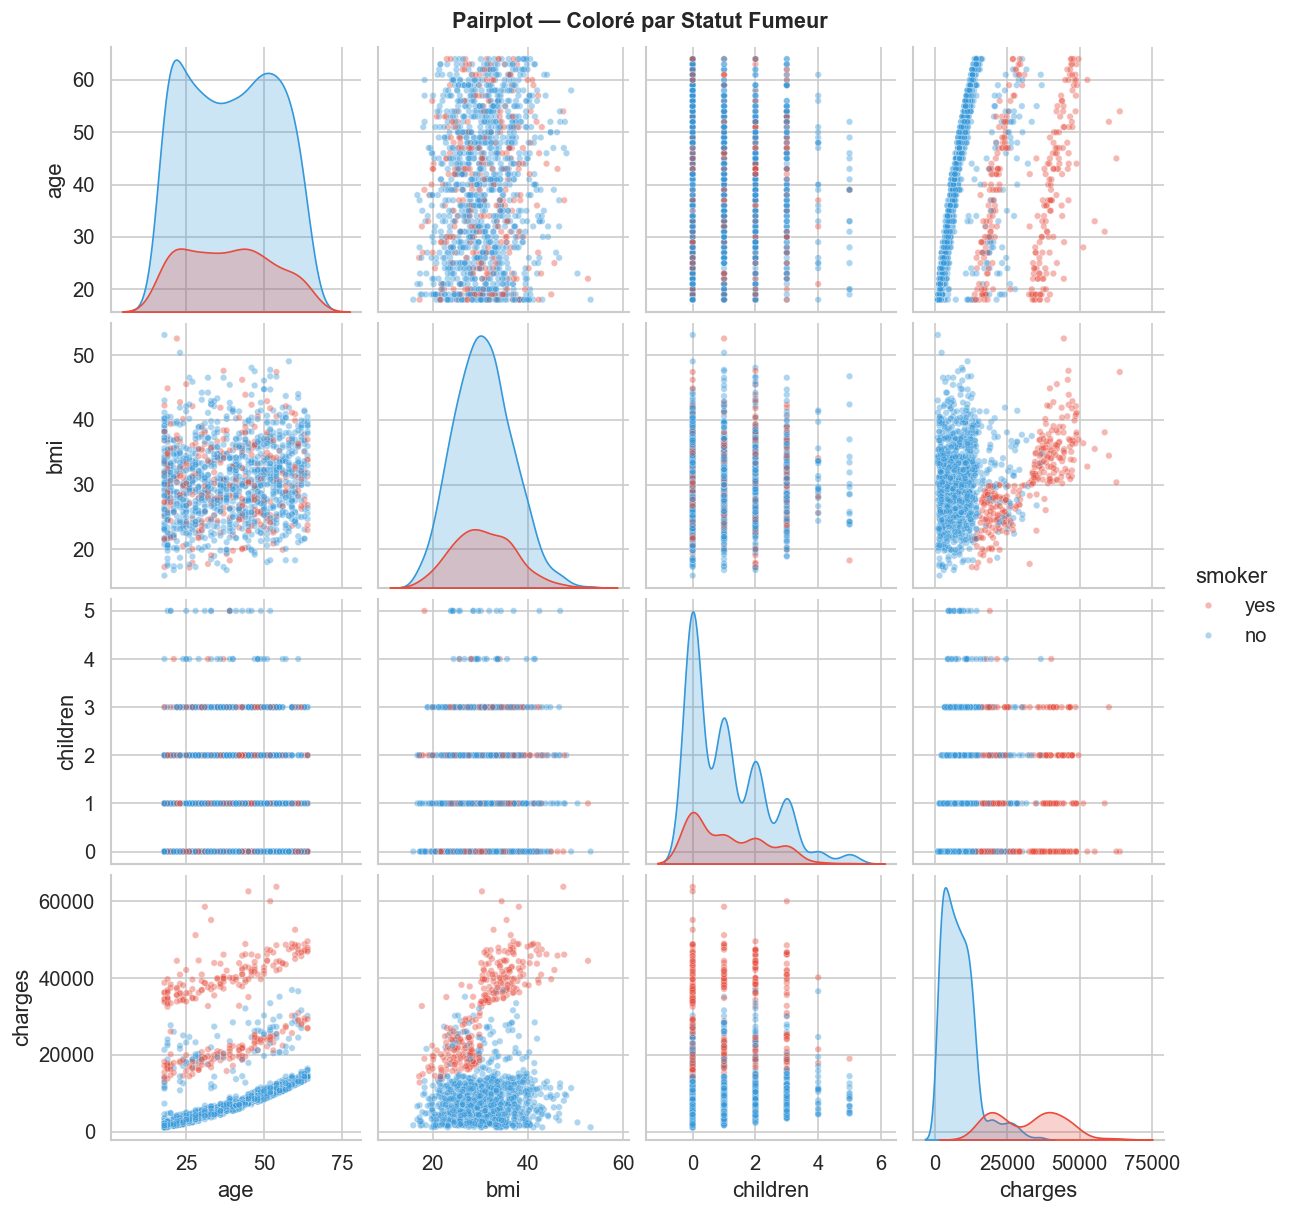

In [35]:
# Pairplot coloré par smoker
pp = sns.pairplot(df[num_vars + ['smoker']], hue='smoker',
                  palette={'yes': '#E74C3C', 'no': '#3498DB'},
                  plot_kws={'alpha': 0.4, 's': 15},
                  diag_kind='kde')
pp.fig.suptitle('Pairplot — Coloré par Statut Fumeur', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('fig_pairplot.png', bbox_inches='tight')
plt.show()

####  Observations — Pairplot

- **`charges` vs `age`** : 3 clusters parallèles distincts — non-fumeurs (bas), fumeurs BMI<30 (intermédiaire), fumeurs BMI≥30 (élevé). La corrélation de Pearson sous-estime cette relation car elle mélange les groupes.
- **`charges` vs `bmi`** : rupture nette à **BMI = 30** uniquement chez les fumeurs → interaction non linéaire `bmi × smoker` invisible dans la heatmap, d'où la nécessité d'une variable d'interaction.
- **`charges` vs `children`** : aucune structure — feature peu informative.

> `smoker` est un **facteur de segmentation dominant** : il crée des sous-populations aux profils de charges radicalement différents, ce qui motive l'ajout de termes d'interaction en Feature Engineering.

### 4.4 Détection des Outliers (Méthode IQR)

In [18]:
def detect_outliers_iqr(data, variable):
    """Détecte les outliers via la méthode IQR."""
    Q1 = data[variable].quantile(0.25)
    Q3 = data[variable].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[variable] < lower) | (data[variable] > upper)]
    return outliers, lower, upper, Q1, Q3, IQR

print('='*65)
print(f"{'Variable':<12} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>10} {'Upper':>10} {'#Outliers':>10}")
print('='*65)
for var in num_vars:
    out, low, up, Q1, Q3, IQR = detect_outliers_iqr(df, var)
    print(f"{var:<12} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {low:>10.2f} {up:>10.2f} {len(out):>10}")
print('='*65)

Variable           Q1       Q3      IQR      Lower      Upper  #Outliers
age             27.00    51.00    24.00      -9.00      87.00          0
bmi             26.30    34.69     8.40      13.70      47.29          9
children         0.00     2.00     2.00      -3.00       5.00          0
charges       4740.29 16639.91 11899.63  -13109.15   34489.35        139


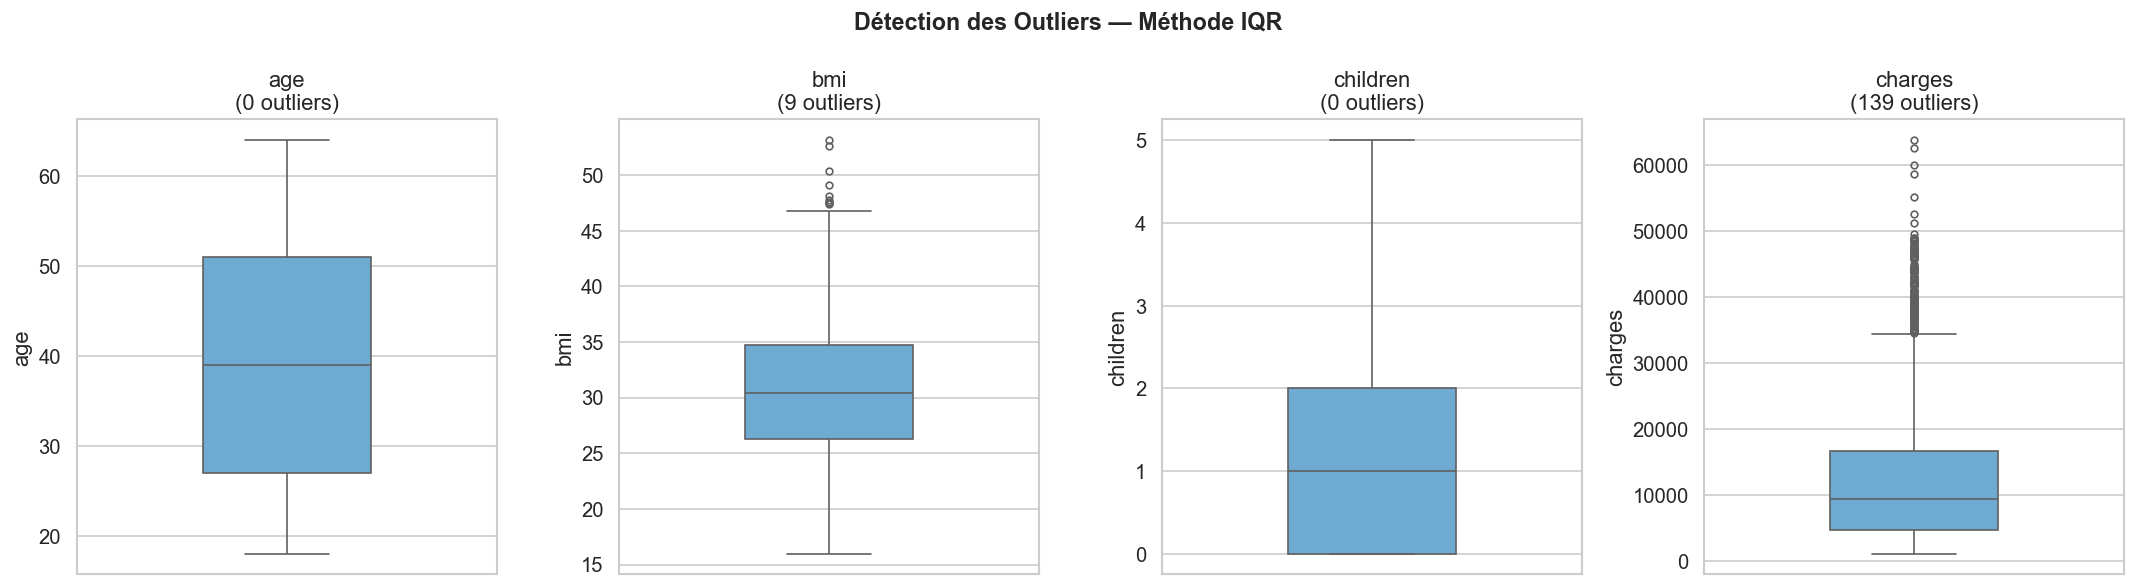

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Détection des Outliers — Méthode IQR', fontsize=14, fontweight='bold')

for i, var in enumerate(num_vars):
    out, low, up, *_ = detect_outliers_iqr(df, var)
    sns.boxplot(y=df[var], ax=axes[i], color='#5DADE2', width=0.4,
                flierprops=dict(marker='o', color='red', markersize=4))
    axes[i].set_title(f'{var}\n({len(out)} outliers)')

plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()

> **Décision :** Les outliers de `charges` correspondent aux **fumeurs obèses** — ils sont réels et porteurs d'information. On les conserve. Les outliers de `bmi` restent dans des plages médicalement observables.

## 5. Nettoyage et Prétraitement

### 5.1 Valeurs Manquantes

In [21]:
missing = df.isnull().sum()
print('Valeurs manquantes par colonne :')
print(missing[missing >= 0].to_string())
print(f'\n Aucune valeur manquante détectée — aucune imputation nécessaire.')

Valeurs manquantes par colonne :
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0

 Aucune valeur manquante détectée — aucune imputation nécessaire.


### 5.2 Gestion des Doublons

In [24]:
n_dup = df.duplicated().sum()
print(f'Nombre de doublons détectés : {n_dup}')
if n_dup > 0:
    print('Doublons identifiés :')
    display(df[df.duplicated(keep=False)])
    df = df.drop_duplicates().reset_index(drop=True)
    print(f' {n_dup} doublon(s) supprimé(s). Nouveau shape : {df.shape}')
else:
    print(' Aucun doublon.')

Nombre de doublons détectés : 0
 Aucun doublon.


### 5.3 Encodage des Variables Catégorielles

> **Justification**
> - **sex, smoker** : Label Encoding car variables binaires (0/1), sans perte d’information et sans risque d’ordre artificiel.
>- **region** : One-Hot Encoding car variable nominale multi-classes sans ordre. Utilisation de `drop_first=True` pour éviter la multicolinéarité.

In [32]:
df_encoded = df.copy()

# Label Encoding pour variables binaires
le = LabelEncoder()
df_encoded['sex']    = le.fit_transform(df_encoded['sex'])    
df_encoded['smoker'] = le.fit_transform(df_encoded['smoker']) 

# One-Hot Encoding pour region
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True, dtype=int)

print('Colonnes après encodage :')
print(df_encoded.columns.tolist())
print(f'\nShape : {df_encoded.shape}')
df_encoded.head(3)

Colonnes après encodage :
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Shape : (1337, 9)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.90,0,1,16884.9240,0,0,1
1,18,1,33.77,1,0,1725.5523,0,1,0
2,28,1,33.00,3,0,4449.4620,0,1,0


### 5.4 Feature Engineering — Variables d'Interaction

Sur la base de l'EDA, deux interactions sont fortement suggérées :

In [35]:
df_encoded['bmi_smoker']   = df_encoded['bmi'] * df_encoded['smoker']  # Interaction BMI × fumeur
df_encoded['age_smoker']   = df_encoded['age'] * df_encoded['smoker']  # Interaction âge × fumeur
df_encoded['age2']         = df_encoded['age'] ** 2                    # Non-linéarité de l'âge
df_encoded['bmi_obese']    = (df_encoded['bmi'] >= 30).astype(int)     # Flag obésité

print('Variables d\'interaction créées.')
df_encoded[['bmi_smoker', 'age_smoker', 'age2', 'bmi_obese']].describe().round(2)

Variables d'interaction créées.


,bmi_smoker,age_smoker,age2,bmi_obese
count,1337.00,1337.00,1337.00,1337.00
mean,6.29,7.89,1735.47,0.53
std,12.72,16.78,1125.56,0.50
min,0.00,0.00,324.00,0.00
25%,0.00,0.00,729.00,0.00
50%,0.00,0.00,1521.00,1.00
75%,0.00,0.00,2601.00,1.00
max,52.58,64.00,4096.00,1.00


In [36]:
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_smoker,age_smoker,age2,bmi_obese
0,19,0,27.900,0,1,16884.92400,0,0,1,27.9,19,361,0
1,18,1,33.770,1,0,1725.55230,0,1,0,0.0,0,324,1
2,28,1,33.000,3,0,4449.46200,0,1,0,0.0,0,784,1
3,33,1,22.705,0,0,21984.47061,1,0,0,0.0,0,1089,0
4,32,1,28.880,0,0,3866.85520,1,0,0,0.0,0,1024,0


### 5.5 Feature Scaling & Train/Test Split

In [37]:
# Définition X et y
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

print(f'Features (X) : {X.shape[1]} colonnes → {list(X.columns)}')
print(f'Target  (y) : {y.shape[0]} observations')

# Split 80/20 stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f'\nTrain : {X_train.shape[0]} | Test : {X_test.shape[0]}')

Features (X) : 12 colonnes → ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker', 'age_smoker', 'age2', 'bmi_obese']
Target  (y) : 1337 observations

Train : 1069 | Test : 268


In [39]:
# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Conversion en DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

# Reset des index
X_train_scaled = X_train_scaled.reset_index(drop=True)
X_test_scaled  = X_test_scaled.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(' Standardisation appliquée (fit sur train uniquement).')
X_train_scaled.describe().round(3).T[['mean', 'std', 'min', 'max']]

 Standardisation appliquée (fit sur train uniquement).


,mean,std,min,max
age,0.0,1.0,-1.515,1.773
sex,0.0,1.0,-1.029,0.971
bmi,0.0,1.0,-2.410,3.734
children,0.0,1.0,-0.908,3.279
smoker,0.0,1.0,-0.500,1.999
region_northwest,-0.0,1.0,-0.573,1.746
region_southeast,0.0,1.0,-0.606,1.651
region_southwest,0.0,1.0,-0.574,1.742
bmi_smoker,0.0,1.0,-0.488,3.742
age_smoker,-0.0,1.0,-0.463,3.420


### 

**Récapitulatif des choix de prétraitement :**

| Étape | Décision | Justification |
|---|---|---|
| Valeurs manquantes | Aucune action | 0 valeurs manquantes dans le dataset |
| Doublons | Aucune action | 0 doublons dans le dataset |
| `sex`, `smoker` | Label Encoding (0/1) | Variables binaires → encodage ordinal sans risque |
| `region` | One-Hot Encoding + drop_first | 4 modalités nominales → évite le dummy variable trap |
| `bmi_smoker`, `age_smoker` | Interaction multiplicative | EDA révèle un effet conditionnel fort — non capturé par Pearson |
| `age²` | Terme polynomial | Non-linéarité de l'effet de l'âge sur les charges |
| `bmi_obese` | Flag binaire (BMI ≥ 30) | Seuil clinique d'obésité — discriminant dans l'EDA |
| Scaling | StandardScaler | Centrer/réduire pour Ridge/Lasso/ElasticNet — évite le data leakage |
| Split | 80% train / 20% test, random_state=42 | Reproductibilité et proportion standard |

---
## 6. Modélisation

### 6.1 Fonctions Utilitaires

In [121]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Entraîne le modèle et retourne les prédictions + modèle."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    print(f"\n[{name}] Modèle entraîné avec succès.")

    return {
        'Model': name,
        'y_pred': y_pred,
        'model_obj': model
    }

### 6.2 Linear Regression (OLS)

In [92]:
results_all = {}
lr = LinearRegression()
res_lr = evaluate_model('Linear Regression', lr,
                         X_train_scaled, y_train,
                         X_test_scaled,  y_test)
results_all['Linear Regression'] = res_lr


[Linear Regression] Modèle entraîné avec succès.


### 6.3 Ridge Regression (L2)

In [93]:
# Recherche du meilleur alpha via RidgeCV
alphas = np.logspace(-3, 4, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
best_alpha_ridge = ridge_cv.alpha_
print(f'Meilleur alpha Ridge (RidgeCV) : {best_alpha_ridge:.4f}')

ridge = Ridge(alpha=best_alpha_ridge)
res_ridge = evaluate_model('Ridge Regression', ridge,
                            X_train_scaled, y_train,
                            X_test_scaled,  y_test)
results_all['Ridge Regression'] = res_ridge

Meilleur alpha Ridge (RidgeCV) : 0.4132

[Ridge Regression] Modèle entraîné avec succès.


### 6.4 Lasso Regression (L1)

In [94]:
# Recherche du meilleur alpha via LassoCV
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
best_alpha_lasso = lasso_cv.alpha_
print(f'Meilleur alpha Lasso (LassoCV) : {best_alpha_lasso:.4f}')

lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000, random_state=RANDOM_STATE)
res_lasso = evaluate_model('Lasso Regression', lasso,
                            X_train_scaled, y_train,
                            X_test_scaled,  y_test)
results_all['Lasso Regression'] = res_lasso

Meilleur alpha Lasso (LassoCV) : 7.7426

[Lasso Regression] Modèle entraîné avec succès.


### 6.5 ElasticNet Regression (L1 + L2)

In [95]:
# Recherche via ElasticNetCV
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]
en_cv = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios,
                     cv=5, random_state=RANDOM_STATE, max_iter=10000)
en_cv.fit(X_train_scaled, y_train)
print(f'Meilleur alpha ElasticNet : {en_cv.alpha_:.4f}')
print(f'Meilleur l1_ratio         : {en_cv.l1_ratio_:.2f}')

enet = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_,
                  max_iter=10000, random_state=RANDOM_STATE)
res_enet = evaluate_model('ElasticNet', enet,
                           X_train_scaled, y_train,
                           X_test_scaled,  y_test)
results_all['ElasticNet'] = res_enet

Meilleur alpha ElasticNet : 7.7426
Meilleur l1_ratio         : 1.00

[ElasticNet] Modèle entraîné avec succès.


### 5.6 Comparaison des Coefficients

Tableau des coefficients :


,Linear Regression,Ridge Regression,Lasso Regression,ElasticNet
age,-562.06,-486.71,-0.00,-0.00
sex,-311.80,-307.98,-298.72,-298.72
bmi,-1245.12,-1216.79,-1172.30,-1172.30
children,876.76,872.66,841.97,841.97
smoker,-8429.49,-8158.58,-8028.29,-8028.29
region_northwest,-210.18,-209.11,-183.71,-183.71
region_southeast,-316.81,-316.33,-295.50,-295.50
region_southwest,-405.45,-404.00,-379.96,-379.96
bmi_smoker,18301.95,18043.19,17888.80,17888.80
age_smoker,-228.36,-244.50,-215.96,-215.96


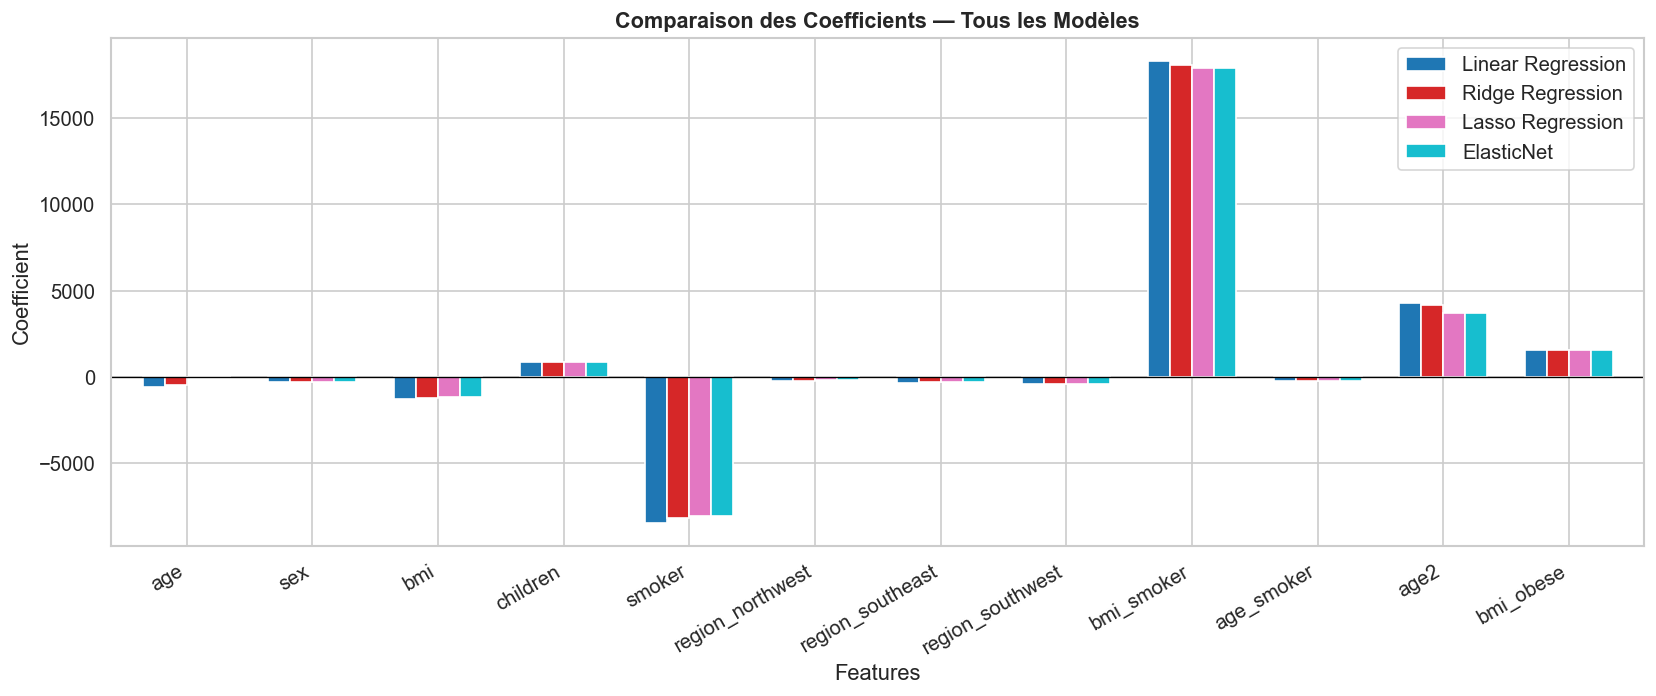

In [96]:
coef_df = pd.DataFrame(index=X.columns)
for name, res in results_all.items():
    coef_df[name] = res['model_obj'].coef_

print('Tableau des coefficients :'); display(coef_df.round(2))

fig, ax = plt.subplots(figsize=(14, 6))
coef_df.plot(kind='bar', ax=ax, width=0.7, colormap='tab10')
ax.set_title('Comparaison des Coefficients — Tous les Modèles', fontsize=13, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Coefficient')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(loc='upper right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_coefficients.png', bbox_inches='tight')
plt.show()

> **Interprétation des coefficients**
> - **smoker et bmi_smoker** : variables les plus influentes (forts coefficients en valeur absolue dans tous les modèles), confirmant l’impact majeur du tabagisme et de son interaction avec le BMI sur les charges médicales.
>- **age et age_smoker** : effet globalement positif de l’âge sur les charges, avec une interaction modifiant cet effet chez les fumeurs.
>- **Ridge Regression** : réduit l’amplitude des coefficients via une régularisation L2, sans supprimer de variables.
>- **Lasso Regression** : effectue une sélection de variables en annulant certains coefficients (*age = 0*), ce qui permet de simplifier légèrement le modèle.
>- **ElasticNet** : dans ce cas, produit des résultats identiques à Lasso, suggérant un réglage proche d’une pénalisation L1 dominante.
>- **Variables de région** : coefficients faibles dans tous les modèles, indiquant une contribution limitée à la prédiction des charges.

## 7. Évaluation des Modèles

In [122]:
def adjusted_r2(r2, n, p):
    """R² ajusté."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error."""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(' Fonctions utilitaires définies.')

def compute_metrics(results, y_true, X_scaled, y_train, X_train_scaled, cv=5):
    """Calcule les métriques pour un dict de résultats (results_all ou results_sel)."""
    n = len(y_true)
    p = X_scaled.shape[1]
    rows = []

    for name, res in results.items():
        y_pred = res['y_pred']

        rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
        mae    = mean_absolute_error(y_true, y_pred)
        r2     = r2_score(y_true, y_pred)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        mape   = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        cv_scores = cross_val_score(res['model_obj'], X_train_scaled, y_train,
                                    cv=cv, scoring='r2')
        rows.append({
            'Model':        name,
            'RMSE':         rmse,
            'MAE':          mae,
            'R²':           r2,
            'Adj. R²':      adj_r2,
            'MAPE (%)':     mape,
            'CV R² (mean)': cv_scores.mean(),
            'CV R² (std)':  cv_scores.std(),
        })

    return pd.DataFrame(rows).set_index('Model')


 Fonctions utilitaires définies.


### 7.1 Métriques

In [149]:
metrics_df = compute_metrics(results_all, y_test, X_test_scaled, y_train, X_train_scaled)

display(metrics_df.style
        .format({'RMSE': '{:,.0f}', 'MAE': '{:,.0f}',
                 'R²': '{:.4f}', 'Adj. R²': '{:.4f}',
                 'MAPE (%)': '{:.2f}',
                 'CV R² (mean)': '{:.4f}', 'CV R² (std)': '{:.4f}'})
        .highlight_max(subset=['R²', 'Adj. R²', 'CV R² (mean)'], color='#90EE90')
        .highlight_min(subset=['RMSE', 'MAE', 'MAPE (%)'], color='#90EE90'))

,RMSE,MAE,R²,Adj. R²,MAPE (%),CV R² (mean),CV R² (std)
Model,,,,,,,
Linear Regression,"4,549","2,806",0.8874,0.8821,32.41,0.8313,0.0222
Ridge Regression,"4,546","2,805",0.8875,0.8822,32.31,0.8313,0.0222
Lasso Regression,"4,538","2,794",0.8879,0.8826,31.83,0.8313,0.0223
ElasticNet,"4,538","2,794",0.8879,0.8826,31.83,0.8313,0.0223


### 7.2 Analyse des Résidus

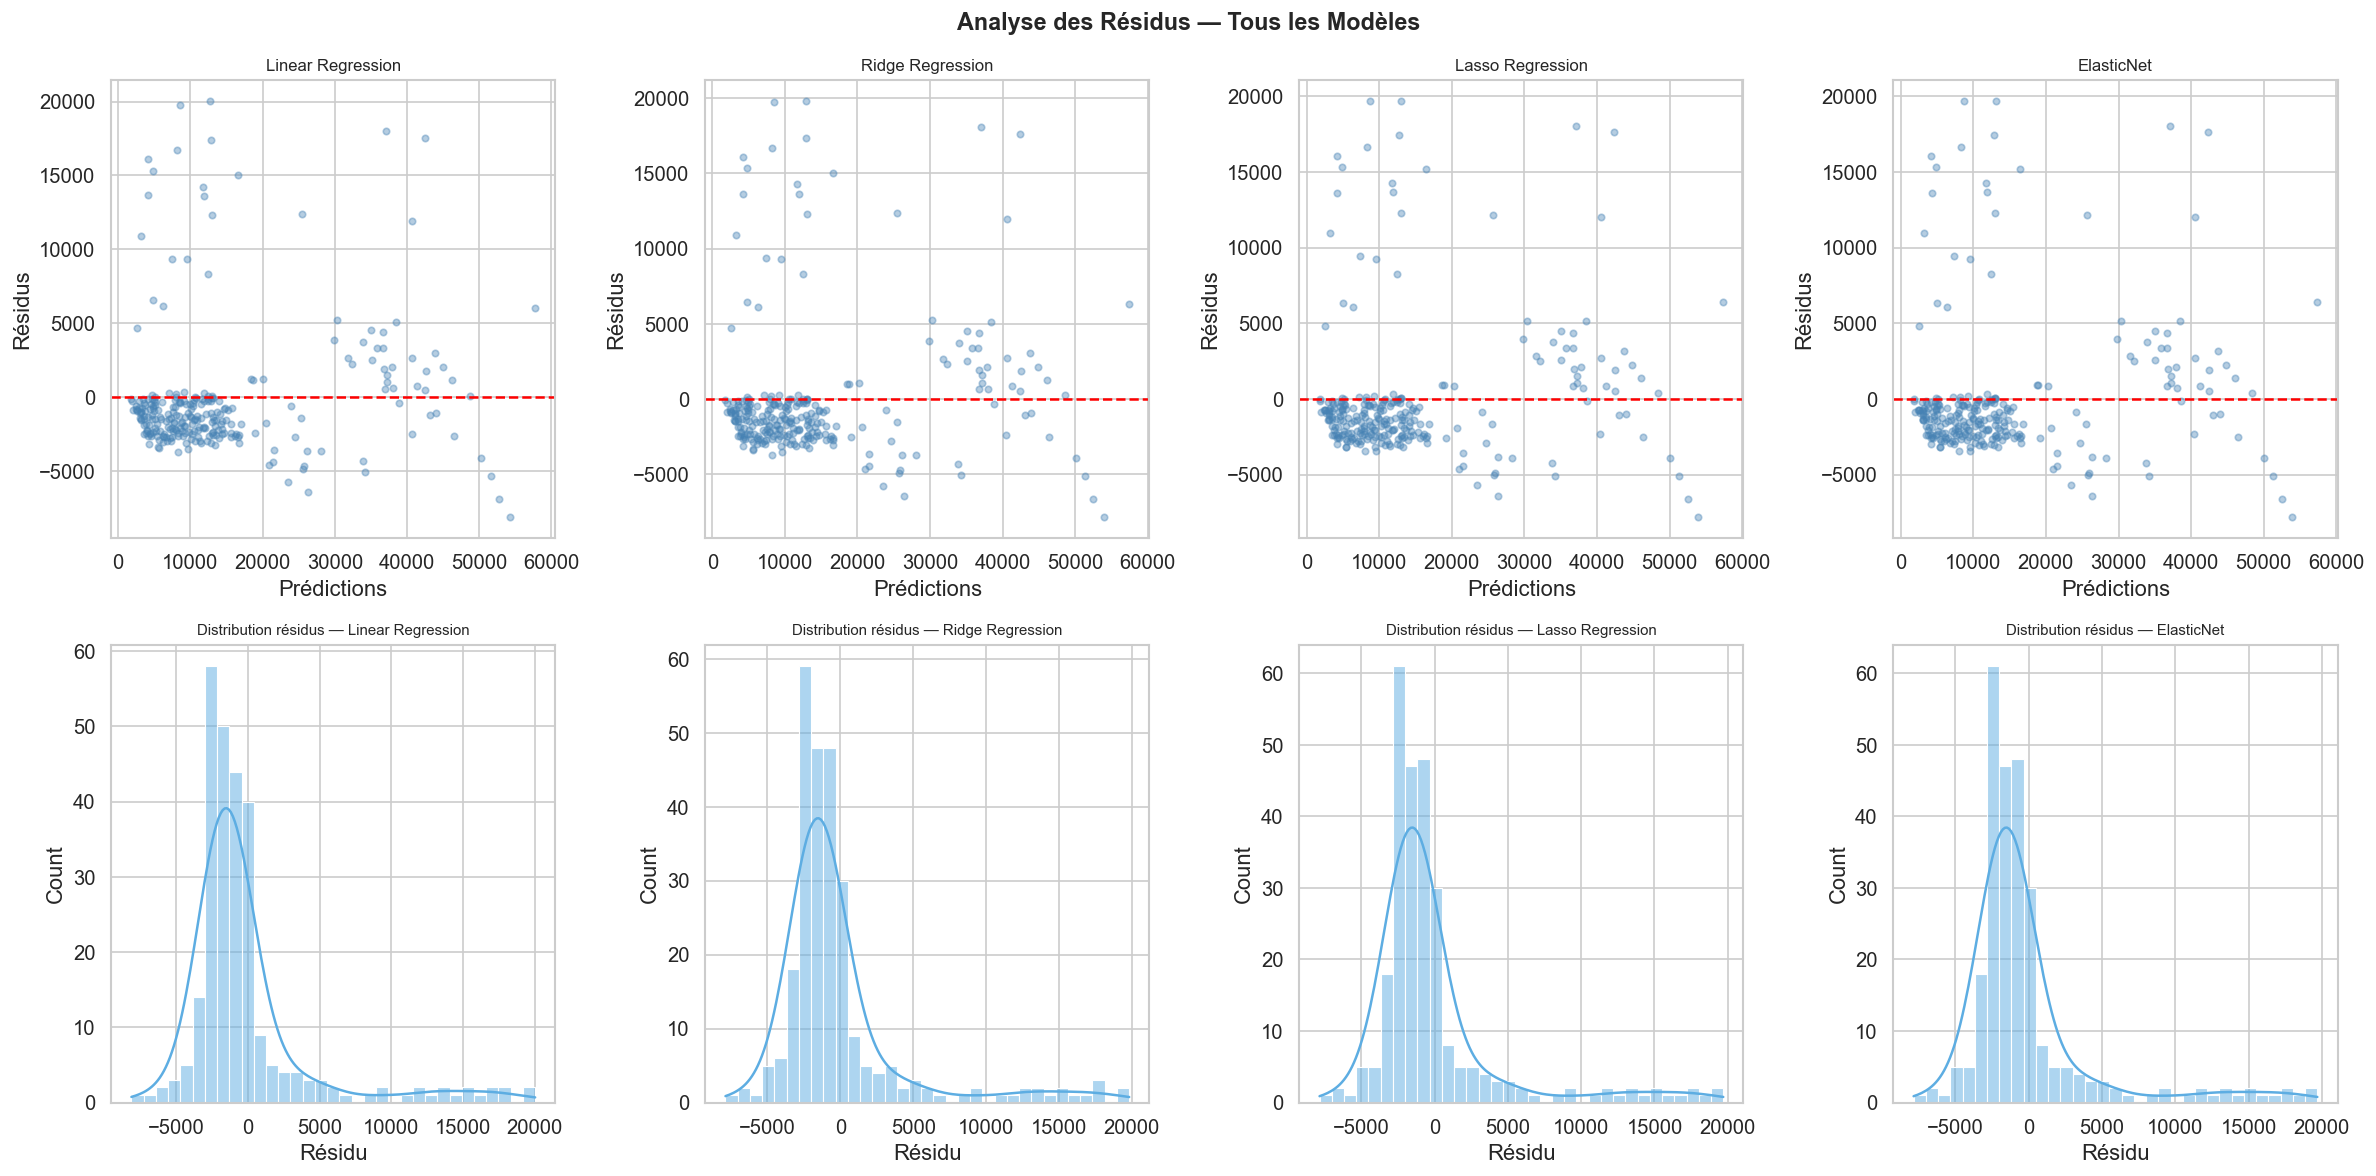

In [124]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Analyse des Résidus — Tous les Modèles', fontsize=14, fontweight='bold')

for col, (name, res) in enumerate(results_all.items()):
    y_pred = res['y_pred']
    residuals = y_test.values - y_pred

    # Scatter résidus vs prédictions
    axes[0, col].scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
    axes[0, col].axhline(0, color='red', linestyle='--')
    axes[0, col].set_title(name, fontsize=10)
    axes[0, col].set_xlabel('Prédictions')
    axes[0, col].set_ylabel('Résidus')

    # Distribution des résidus
    sns.histplot(residuals, kde=True, ax=axes[1, col], color='#5DADE2', edgecolor='white')
    axes[1, col].set_title(f'Distribution résidus — {name}', fontsize=9)
    axes[1, col].set_xlabel('Résidu')

plt.tight_layout()
plt.savefig('fig_residuals.png', bbox_inches='tight')
plt.show()

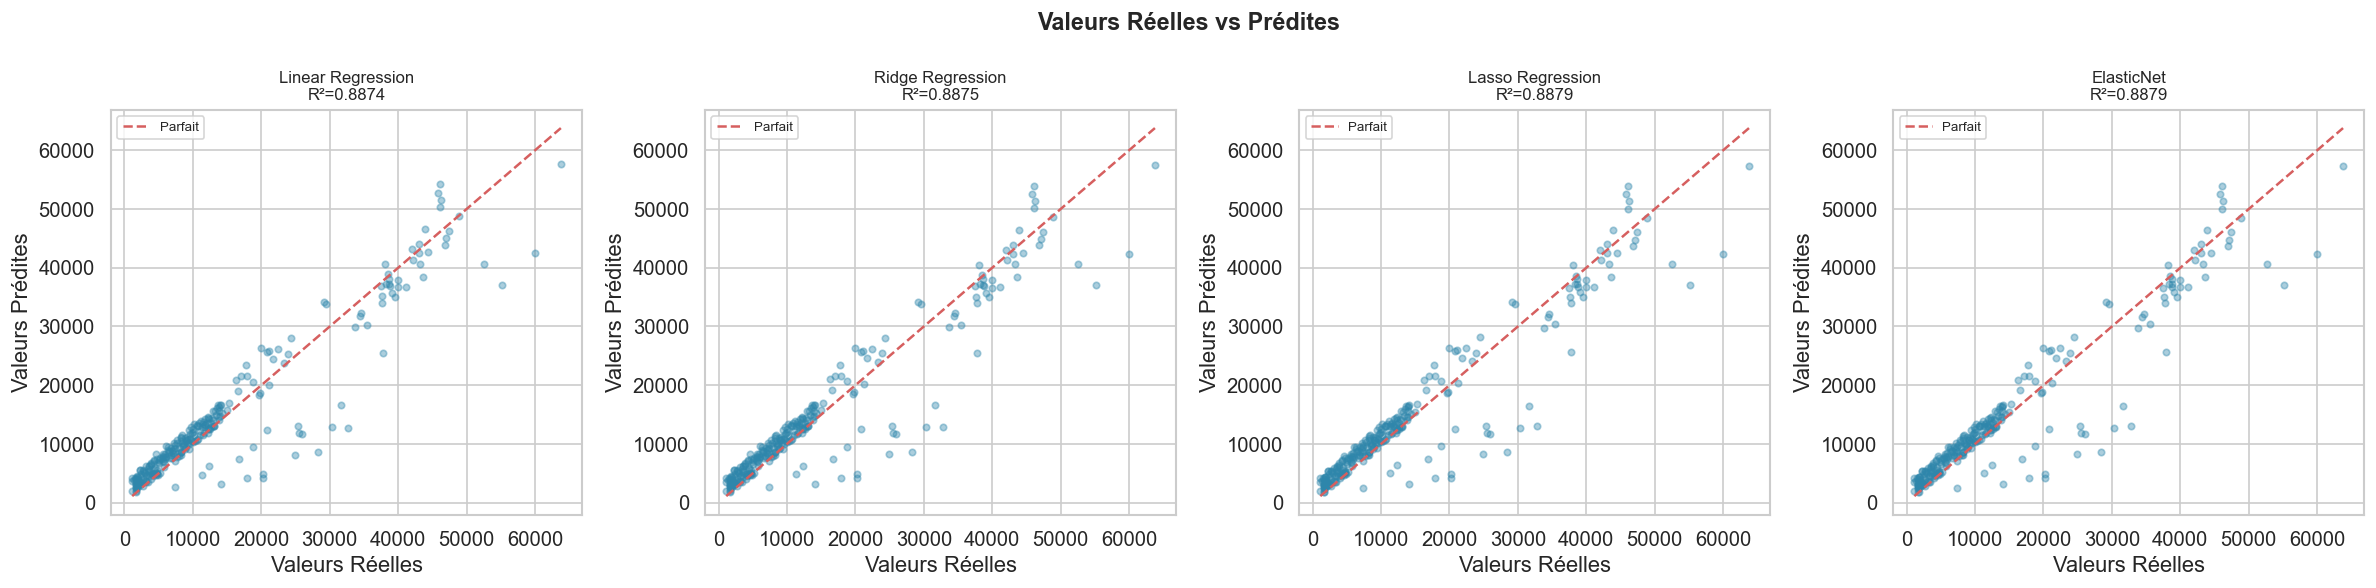

In [125]:
# Réel vs Prédit
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Valeurs Réelles vs Prédites', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results_all.items()):
    y_pred = res['y_pred']
    r2 = metrics_df.loc[name, 'R²']   
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='#2E86AB')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', label='Parfait')
    ax.set_xlabel('Valeurs Réelles')
    ax.set_ylabel('Valeurs Prédites')
    ax.set_title(f'{name}\nR²={r2:.4f}', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_actual_vs_pred.png', bbox_inches='tight')
plt.show()

### 7.3 Tableau Comparatif

In [150]:
display(metrics_df)

,RMSE,MAE,R²,Adj. R²,MAPE (%),CV R² (mean),CV R² (std)
Model,,,,,,,
Linear Regression,4549.419232,2806.185385,0.887366,0.882065,32.405255,0.831279,0.022157
Ridge Regression,4545.897046,2804.970655,0.887540,0.882248,32.313095,0.831314,0.022157
Lasso Regression,4538.430496,2794.421793,0.887909,0.882634,31.833870,0.831323,0.022338
ElasticNet,4538.430496,2794.421793,0.887909,0.882634,31.833870,0.831323,0.022338


> **Analyse des métriques**
>- Tous les modèles atteignent un **R² similaire**, ce qui indique que les différences de régularisation sont marginales sur ce dataset et que le signal est principalement linéaire après feature engineering.
>- Le **RMSE** reflète des erreurs de l’ordre de plusieurs milliers de dollars, principalement concentrées sur les cas extrêmes (fumeurs obèses avec charges élevées).
>- Le **CV R² (5-fold)** est cohérent avec le R² test, ce qui indique l’absence de surapprentissage significatif.

> **Analyse des résidus**
>- Le scatter *résidus vs prédictions* montre une **hétéroscédasticité** : les erreurs augmentent avec les valeurs prédites, notamment pour les charges élevées.
>- La distribution des résidus est globalement **centrée autour de 0**, mais avec des queues épaisses, suggérant la présence d’outliers.
>- Le graphique *réel vs prédit* montre un bon alignement global sur la diagonale, avec une légère sous-estimation des valeurs extrêmes.

> **Meilleur modèle identifié**
>Sur ce dataset, la régression linéaire et Ridge offrent le meilleur compromis entre performance et interprétabilité, car les modèles régularisés n’apportent qu’un gain marginal.
>Lasso et ElasticNet n’améliorent pas significativement les performances, ce qui suggère que la majorité des variables sont pertinentes et contribuent à la prédiction.

## 8. Sélection de Features

### 8.1 Backward Elimination

In [126]:
def backward_elimination(X, y, significance_level=0.05):
    """Backward Elimination via OLS statsmodels — itératif."""
    features = list(X.columns)
    iteration = 0
    history = []

    while True:
        X_with_const = sm.add_constant(X[features])
        model = sm.OLS(y, X_with_const).fit()
        pvalues = model.pvalues.drop('const')
        max_pval = pvalues.max()
        max_feat = pvalues.idxmax()

        history.append({
            'Iteration': iteration,
            'Features restantes': len(features),
            'Feature max p-value': max_feat,
            'Max p-value': round(max_pval, 6),
            'Action': 'ÉLIMINÉ' if max_pval > significance_level else 'CONSERVÉ (stop)'
        })

        if max_pval > significance_level:
            print(f'Iter {iteration}: Suppression de [{max_feat}] — p-value={max_pval:.6f}')
            features.remove(max_feat)
            iteration += 1
        else:
            print(f'\n Convergence à l\'itération {iteration}. Toutes les p-values < {significance_level}')
            break

    return features, pd.DataFrame(history), model


selected_features, be_history, final_ols = backward_elimination(X_train_scaled, y_train)
print(f'\nFeatures sélectionnées ({len(selected_features)}) : {selected_features}')

Iter 0: Suppression de [age_smoker] — p-value=0.598745
Iter 1: Suppression de [age] — p-value=0.554069
Iter 2: Suppression de [region_northwest] — p-value=0.246487
Iter 3: Suppression de [region_southeast] — p-value=0.202936
Iter 4: Suppression de [region_southwest] — p-value=0.124588

 Convergence à l'itération 5. Toutes les p-values < 0.05

Features sélectionnées (7) : ['sex', 'bmi', 'children', 'smoker', 'bmi_smoker', 'age2', 'bmi_obese']


In [127]:
print('\n── Historique Backward Elimination ──')
display(be_history)

print('\n── Résumé OLS Final (statsmodels) ──')
print(final_ols.summary())


── Historique Backward Elimination ──


,Iteration,Features restantes,Feature max p-value,Max p-value,Action
0,0,12,age_smoker,0.598745,ÉLIMINÉ
1,1,11,age,0.554069,ÉLIMINÉ
2,2,10,region_northwest,0.246487,ÉLIMINÉ
3,3,9,region_southeast,0.202936,ÉLIMINÉ
4,4,8,region_southwest,0.124588,ÉLIMINÉ
5,5,7,sex,0.039427,CONSERVÉ (stop)



── Résumé OLS Final (statsmodels) ──
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     761.1
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:10:00   Log-Likelihood:                -10571.
No. Observations:                1069   AIC:                         2.116e+04
Df Residuals:                    1061   BIC:                         2.120e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.

### 8.2 RFE — Recursive Feature Elimination

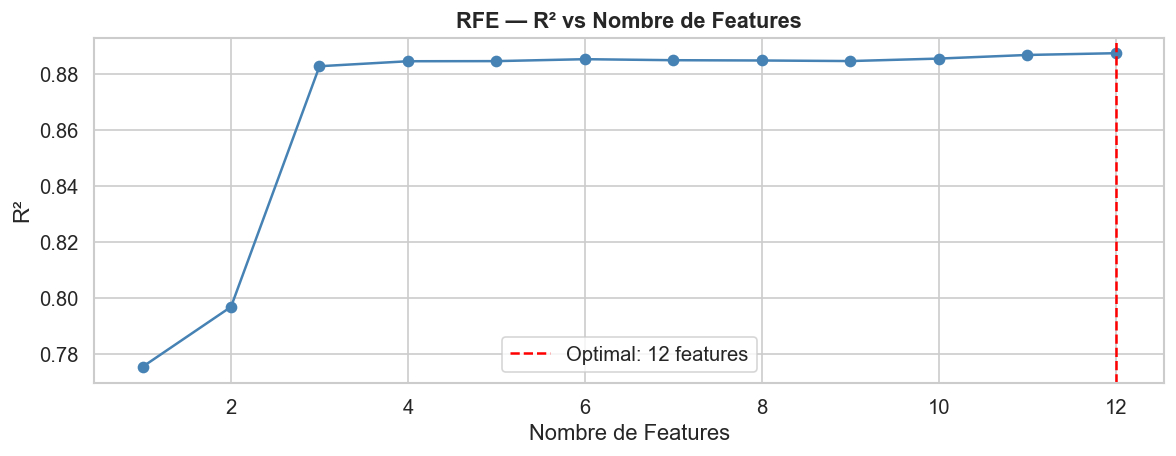

Nombre optimal de features (RFE) : 12
Features RFE : ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker', 'age_smoker', 'age2', 'bmi_obese']


In [128]:
# RFE avec Linear Regression, recherche du nombre optimal de features
rfe_scores = []
for n_feat in range(1, X_train_scaled.shape[1] + 1):
    rfe = RFE(LinearRegression(), n_features_to_select=n_feat)
    rfe.fit(X_train_scaled, y_train)
    y_pred_rfe = rfe.predict(X_test_scaled)
    rfe_scores.append({'n_features': n_feat, 'R²': r2_score(y_test, y_pred_rfe)})

rfe_df = pd.DataFrame(rfe_scores)
best_n = rfe_df.loc[rfe_df['R²'].idxmax(), 'n_features']

plt.figure(figsize=(10, 4))
plt.plot(rfe_df['n_features'], rfe_df['R²'], marker='o', color='steelblue')
plt.axvline(best_n, color='red', linestyle='--', label=f'Optimal: {int(best_n)} features')
plt.title('RFE — R² vs Nombre de Features', fontsize=13, fontweight='bold')
plt.xlabel('Nombre de Features'); plt.ylabel('R²')
plt.legend(); plt.tight_layout()
plt.savefig('fig_rfe.png', bbox_inches='tight')
plt.show()
print(f'Nombre optimal de features (RFE) : {int(best_n)}')

# Features sélectionnées par RFE
rfe_final = RFE(LinearRegression(), n_features_to_select=int(best_n))
rfe_final.fit(X_train_scaled, y_train)
rfe_features = X_train_scaled.columns[rfe_final.support_].tolist()
print(f'Features RFE : {rfe_features}')

### 8.3 Analyse Lasso

Features mises à 0 par Lasso (1) : ['age']
Features conservées (11) : ['smoker', 'bmi', 'region_southwest', 'sex', 'region_southeast', 'age_smoker', 'region_northwest', 'children', 'bmi_obese', 'age2', 'bmi_smoker']


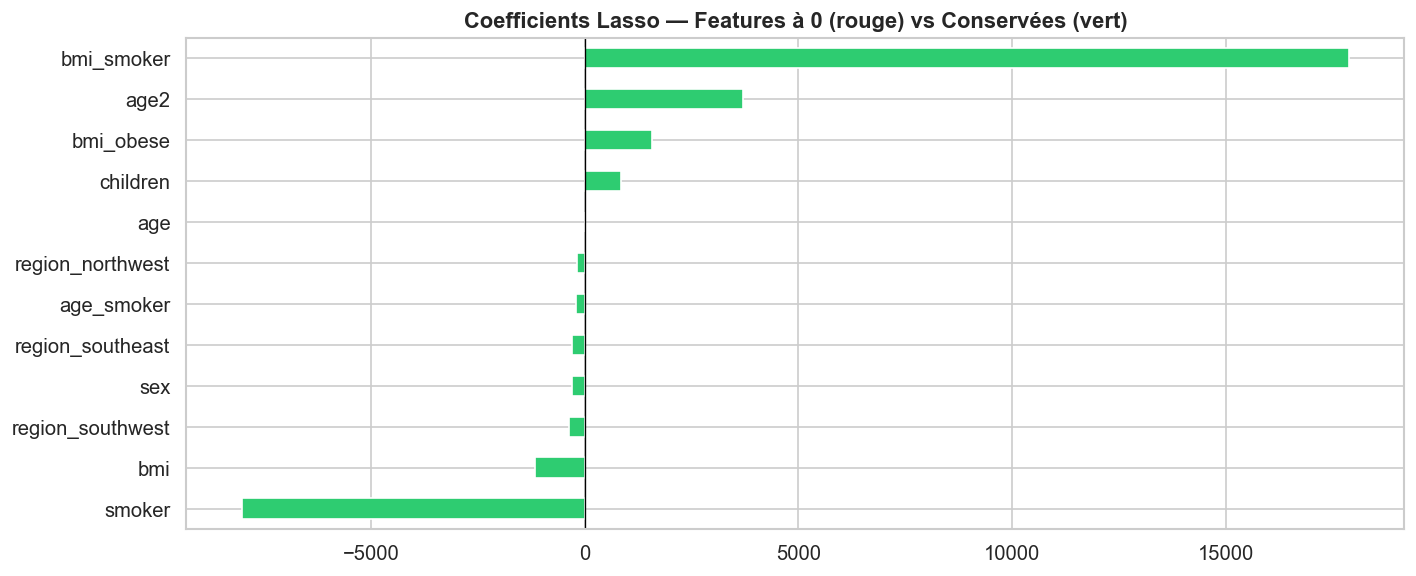

In [129]:
lasso_coefs = pd.Series(lasso.coef_, index=X.columns).sort_values()
lasso_zero  = lasso_coefs[lasso_coefs == 0].index.tolist()
lasso_nonzero = lasso_coefs[lasso_coefs != 0].index.tolist()

print(f'Features mises à 0 par Lasso ({len(lasso_zero)}) : {lasso_zero}')
print(f'Features conservées ({len(lasso_nonzero)}) : {lasso_nonzero}')

colors = ['#E74C3C' if c == 0 else '#2ECC71' for c in lasso_coefs]
plt.figure(figsize=(12, 5))
lasso_coefs.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coefficients Lasso — Features à 0 (rouge) vs Conservées (vert)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lasso_coefs.png', bbox_inches='tight')
plt.show()

### 8.4 Sélection Finale des Features

In [153]:
# Union des features validées par Backward Elimination et Lasso
final_features = list(set(selected_features) & set(lasso_nonzero))
final_features = [f for f in X.columns if f in final_features]  # Préserve l'ordre

print(f'Features finales retenues ({len(final_features)}) :')
for f in final_features:
    print(f'  ✓ {f}')

Features finales retenues (7) :
  ✓ sex
  ✓ bmi
  ✓ children
  ✓ smoker
  ✓ bmi_smoker
  ✓ age2
  ✓ bmi_obese


**Tableau synthétique des méthodes appliquées :**

| Méthode | Features éliminées | Features conservées | Critère |
|---|---|---|---|
| Backward Elimination | Features avec p-value > 0.05 | Toutes les features statistiquement significatives | p-value OLS |
| RFE | Features de rang inférieur | N features optimales (maximisation R²) | Score R² |
| Lasso (L1) | Features avec coef = 0 | Features avec coef ≠ 0 | Régularisation L1 |

**Justification de la sélection finale :**
                             
La sélection finale est obtenue par intersection entre les features issues de la Backward Elimination et celles conservées par Lasso, garantissant ainsi une double validation statistique et par régularisation.

Les variables éliminées présentent soit une faible significativité statistique (p-value élevée), soit une contribution nulle dans le modèle Lasso.

Les features retenues constituent un sous-ensemble robuste et parcimonieux, respectant le principe de parcimonie (Occam’s Razor), tout en conservant des performances prédictives élevées.

## 9. Comparaison — All Features vs Selected Features

In [155]:
# Sous-ensembles
X_train_sel = X_train_scaled[final_features]
X_test_sel  = X_test_scaled[final_features]

results_sel = {}
models_to_retrain = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=best_alpha_ridge),
    'Lasso Regression' : Lasso(alpha=best_alpha_lasso, max_iter=10000, random_state=RANDOM_STATE),
    'ElasticNet'       : ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_,
                                    max_iter=10000, random_state=RANDOM_STATE)
}

for name, model in models_to_retrain.items():
    res = evaluate_model(name, model, X_train_sel, y_train, X_test_sel, y_test)
    results_sel[name] = res


[Linear Regression] Modèle entraîné avec succès.

[Ridge Regression] Modèle entraîné avec succès.

[Lasso Regression] Modèle entraîné avec succès.

[ElasticNet] Modèle entraîné avec succès.


In [156]:
metrics_sel_df = compute_metrics(results_sel, y_test, X_test_sel, y_train, X_train_sel)

comparison_df = pd.concat([
    metrics_df[['RMSE','MAE','R²','Adj. R²','MAPE (%)']].assign(Features='All Features'),
    metrics_sel_df[['RMSE','MAE','R²','Adj. R²','MAPE (%)']].assign(Features='Selected Features')
]).set_index('Features', append=True)

display(comparison_df.style
        .format({'RMSE': '{:,.0f}', 'MAE': '{:,.0f}',
                 'R²': '{:.4f}', 'Adj. R²': '{:.4f}', 'MAPE (%)': '{:.2f}'})
        .background_gradient(subset=['R²'], cmap='RdYlGn'))

,,RMSE,MAE,R²,Adj. R²,MAPE (%)
Model,Features,,,,,
Linear Regression,All Features,"4,549","2,806",0.8874,0.8821,32.41
Ridge Regression,All Features,"4,546","2,805",0.8875,0.8822,32.31
Lasso Regression,All Features,"4,538","2,794",0.8879,0.8826,31.83
ElasticNet,All Features,"4,538","2,794",0.8879,0.8826,31.83
Linear Regression,Selected Features,"4,594","2,829",0.8851,0.8820,32.60
Ridge Regression,Selected Features,"4,591","2,828",0.8853,0.8822,32.61
Lasso Regression,Selected Features,"4,587","2,825",0.8855,0.8824,32.61
ElasticNet,Selected Features,"4,587","2,825",0.8855,0.8824,32.61


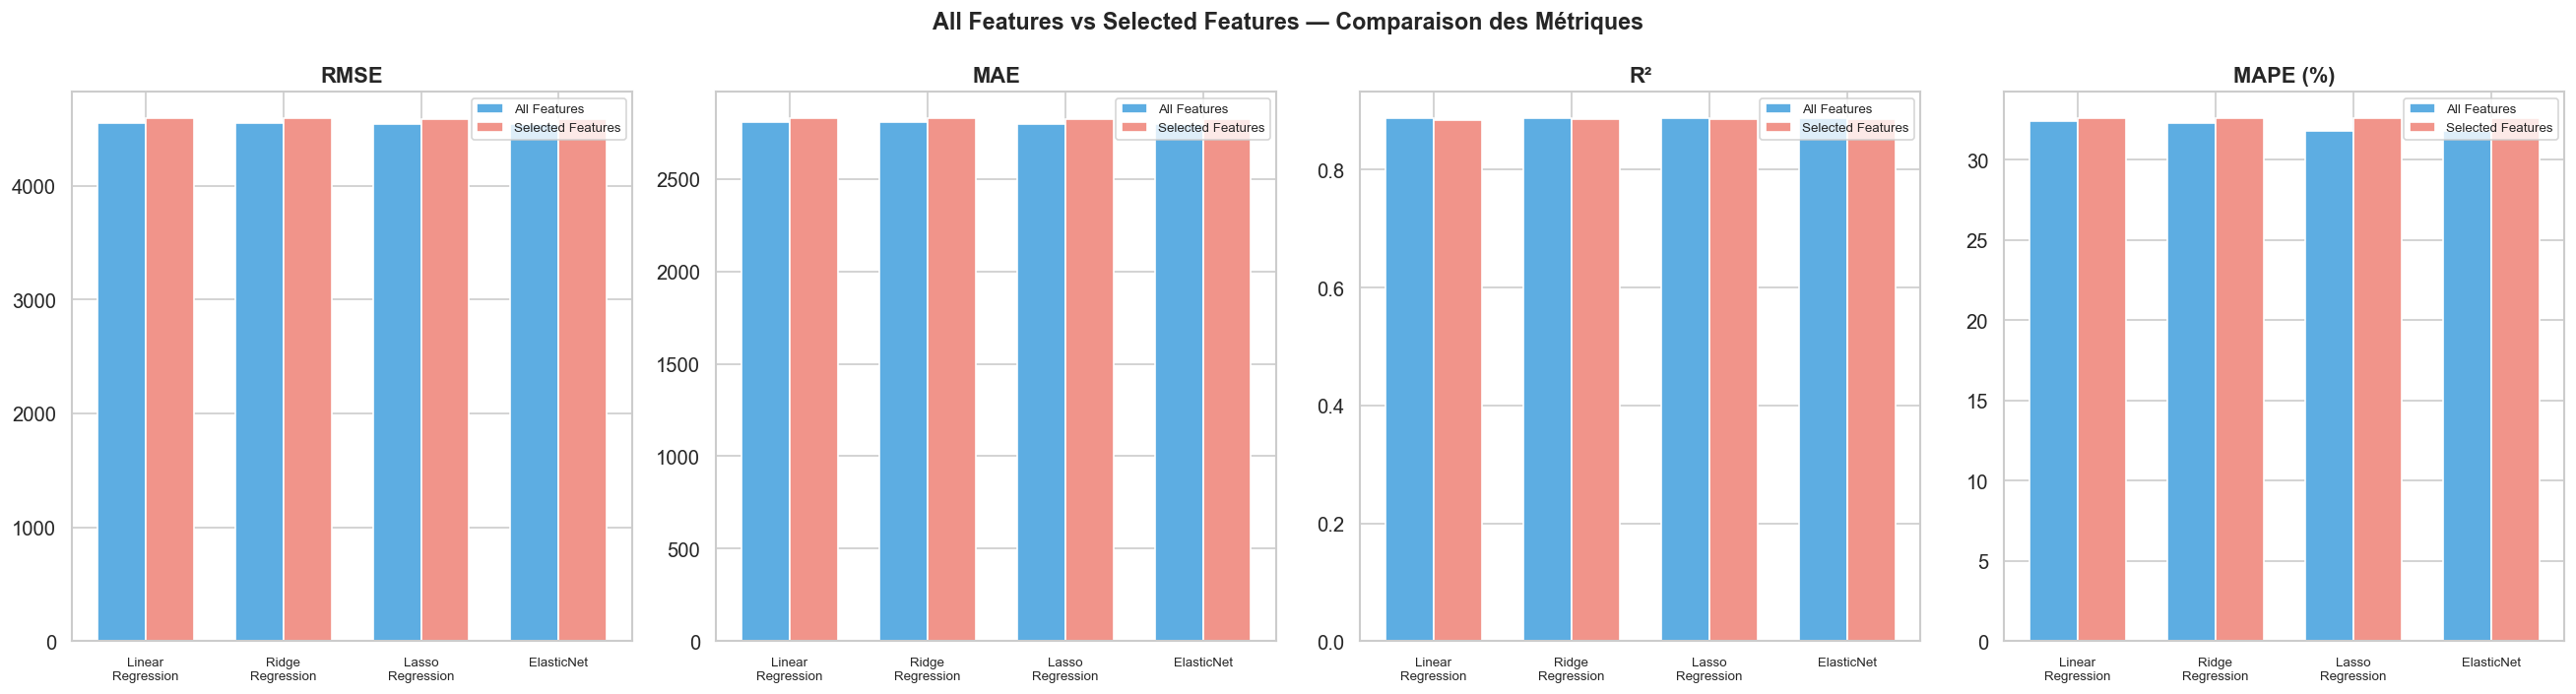

In [157]:
# Bar chart groupé
metrics_to_plot = ['RMSE', 'MAE', 'R²', 'MAPE (%)']

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('All Features vs Selected Features — Comparaison des Métriques',
             fontsize=14, fontweight='bold')

models_list = list(metrics_df.index)
x = np.arange(len(models_list))
width = 0.35

for ax, metric in zip(axes, metrics_to_plot):
    vals_all = metrics_df.loc[models_list, metric]
    vals_sel = metrics_sel_df.loc[models_list, metric]

    ax.bar(x - width/2, vals_all, width, label='All Features',color='#5DADE2')
    ax.bar(x + width/2, vals_sel, width, label='Selected Features', color='#F1948A')

    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_comparison.png', bbox_inches='tight')
plt.show()

### Analyse et Discussion

#### Impact de la sélection de features :

| Critère | Observation |
|----------|-------------|
| R² | Globalement stable, avec une légère diminution après sélection des features |
| RMSE / MAE | Légère augmentation des erreurs sur le dataset réduit, mais variation faible |
| Complexité | Réduction du nombre de variables, améliorant l’interprétabilité du modèle |
| Adj. R² | Reste stable, indiquant que la suppression de variables peu informatives n’affecte pas fortement le pouvoir explicatif |

#### Conclusions :

La sélection de features ne conduit pas à une amélioration significative des performances, mais permet de simplifier le modèle sans dégradation importante.

Les modèles entraînés sur toutes les features et sur les features sélectionnées présentent des performances globalement proches, ce qui confirme que le signal principal est déjà bien capturé par les variables les plus importantes.

> **Recommandation finale**
>Le modèle avec features sélectionnées peut être privilégié pour des raisons d’interprétabilité et de simplicité, tandis que les modèles complets restent légèrement plus performants en termes d’erreur.

## 10. Conclusion

### 10.1 Résumé des Résultats

In [158]:
# Identification du meilleur modèle
best_model_name = metrics_df['R²'].idxmax()
best_r2         = metrics_df.loc[best_model_name, 'R²']
best_rmse       = metrics_df.loc[best_model_name, 'RMSE']

print('═' * 60)
print(f'  MEILLEUR MODÈLE : {best_model_name}')
print(f'  R²              : {best_r2:.4f}')
print(f'  RMSE            : {best_rmse:,.0f} USD')
print('═' * 60)

# Features les plus importantes
lr_coef = pd.Series(results_all['Linear Regression']['model_obj'].coef_,
                    index=X.columns).abs().sort_values(ascending=False)
print('\n Top 5 Features (|coefficient| Linear Regression) :')
for i, (feat, val) in enumerate(lr_coef.head(5).items(), 1):
    print(f'  {i}. {feat:<20} {val:>10.2f}')

════════════════════════════════════════════════════════════
  MEILLEUR MODÈLE : Lasso Regression
  R²              : 0.8879
  RMSE            : 4,538 USD
════════════════════════════════════════════════════════════

 Top 5 Features (|coefficient| Linear Regression) :
  1. bmi_smoker             18301.95
  2. smoker                  8429.49
  3. age2                    4267.64
  4. bmi_obese               1590.94
  5. bmi                     1245.12


### 10.2 Observations Clés

| Facteur | Impact |
|---|---|
| **smoker** | Variable la plus déterminante — les fumeurs paient en moyenne ~3× plus que les non-fumeurs |
| **bmi_smoker** | L'interaction BMI×Fumeur révèle un effet multiplicatif non-linéaire |
| **age** | Relation positive avec les charges — chaque année supplémentaire augmente la prime |
| **bmi** | Impact modéré seul, mais critique combiné avec `smoker` |
| **region** | Faible influence — la géographie compte peu dans ce dataset |

### 10.3 Limites du Projet

- **Taille du dataset** : 1 339 observations — limites pour la généralisation
- **Hypothèse de linéarité** : même avec les interactions, des non-linéarités résiduelles existent (3 clusters visibles dans le scatter age/charges)
- **Variables manquantes** : antécédents médicaux, niveau de revenus, type de couverture

### 10.4 Perspectives d'Amélioration

1. **Modèles non-linéaires** : Random Forest, XGBoost, LightGBM
2. **Feature Engineering avancé** : transformations log sur `charges`, termes polynomiaux
3. **Modélisation par segments** : entraîner des modèles séparés fumeurs/non-fumeurs
4. **Collecte de données** : données longitudinales, historique médical